In [1]:
model_ckpt = "meta-llama/Llama-3.2-1B"

In [2]:
import itertools
import random

import transformers
import plotly.express
import plotly.graph_objects
import torch
import sklearn.decomposition
import PIL.Image
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from torch import Tensor

In [3]:
def pca(embs: Tensor, low_dim: int) -> Tensor:
    pca = sklearn.decomposition.PCA(n_components=low_dim)
    reduced_embs = pca.fit_transform(embs.detach().numpy())
    return torch.tensor(reduced_embs)

def fourier(embs: Tensor) -> Tensor:
    return torch.fft.fft(embs, dim=0)

def vis_emb(embs: Tensor, colorful: bool) -> PIL.Image.Image:
    x = embs.cpu().detach()
    x_normalized = (x - x.min()) / (x.max() - x.min())
    theme = matplotlib.colormaps["Blues"]
    if colorful:
        x_normalized = theme(x_normalized)
    else:
        x_normalized = x_normalized.numpy()
    vis = PIL.Image.fromarray((x_normalized * 255).astype(np.uint8))
    return vis

model = transformers.AutoModelForCausalLM.from_pretrained(model_ckpt).eval()
tokenizer = transformers.AutoTokenizer.from_pretrained(model_ckpt)


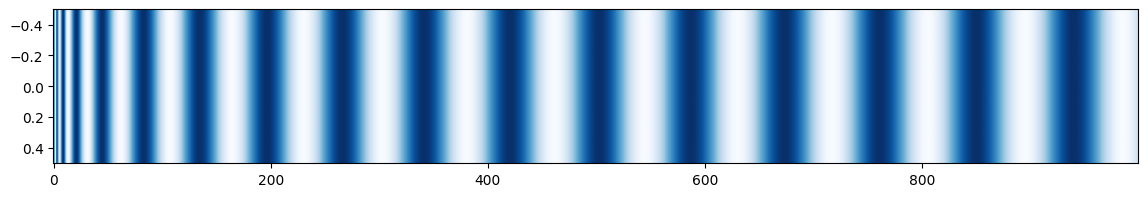

In [7]:
t = np.arange(0, 1000)
freq_initial = 0.01
freq_acceler = 1
y = np.sin(2 * np.pi * freq_initial * t + 2 * np.pi * freq_acceler * np.log(t + 1e-4))

plt.figure(figsize=(14, 2))
plt.imshow(y[np.newaxis, :], aspect="auto", cmap="Blues")
plt.show()

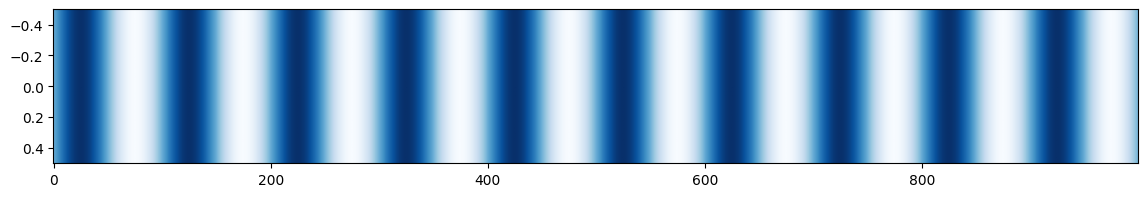

In [5]:
t = np.arange(0, 1000)
freq_initial = 0.01
y = np.sin(2 * np.pi * freq_initial * t)

plt.figure(figsize=(14, 2))
plt.imshow(y[np.newaxis, :], aspect="auto", cmap="Blues")
plt.show()

In [140]:
def sinusoidal_encode(
    x: Tensor,
    embedding_dim: int,
    min_value: int,
    max_value: int,
    use_l2_norm: bool = False,
    norm_const: float | None = None,
) -> Tensor:
    """
    Encodes a tensor of numbers into a sinusoidal representation, inspired by how absolute positional
    encoding works in transformers.

    The encoding is an evaluation of a sine and cosine function at different frequencies, where the
    frequency is determined by the embedding dimension and the allowed range of the input values.

    >>> sinusoidal_encode(
    ...     torch.tensor([-5, 2, 1, 0]),
    ...     embedding_dim=6,
    ...     min_value=-5,
    ...     max_value=5,
    ... )
    tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
            [ 0.6570,  0.7539, -0.1073, -0.9942,  0.9980,  0.0627],
            [-0.2794,  0.9602,  0.3491, -0.9371,  0.9616,  0.2746],
            [-0.9589,  0.2837,  0.7317, -0.6816,  0.8806,  0.4738]])
    """

    if embedding_dim % 2 != 0 and not use_l2_norm:
        raise ValueError("Embedding dimension must be even")

    if use_l2_norm:
        if embedding_dim % 2 == 0:
            reserved_dim = 2
        else:
            reserved_dim = 1
        embedding_dim -= reserved_dim
    else:
        reserved_dim = 0  # will not be used

    domain = max_value - min_value
    y_shape = x.shape + (embedding_dim,)
    y = torch.zeros(y_shape, device=x.device)
    even_indices = torch.arange(0, embedding_dim, 2)
    log_term = torch.log(torch.tensor(domain)) / embedding_dim
    div_term = torch.exp(even_indices * -log_term)
    x = x - min_value
    values = x.unsqueeze(-1).float() * div_term
    y[..., 0::2] = torch.sin(values)
    y[..., 1::2] = torch.cos(values)

    if use_l2_norm:
        y = torch.cat([y, torch.ones_like(y[..., :reserved_dim])], dim=-1)
        y /= y.norm(dim=-1, keepdim=True, p=2)

    if norm_const is not None:
        y *= norm_const

    return y



class ClassifierProbe(torch.nn.Module):
    def __init__(self, emb_dim: int, hidden_dim: int, basis: torch.Tensor, heldout_mask: torch.Tensor):
        super().__init__()
        self.emb_to_latent = torch.nn.Linear(emb_dim, hidden_dim, bias=True)
        self.basis_to_latent = torch.nn.Linear(basis.shape[-1], hidden_dim, bias=True)
        self.basis: torch.nn.Buffer
        self.heldout_mask: torch.nn.Buffer
        self.register_buffer("basis", basis)
        self.register_buffer("heldout_mask", heldout_mask)
        
    def forward(self, x: Tensor, holdout_eval_tokens: bool) -> Tensor:
        latent_x = self.emb_to_latent(x)
        # during training, model learns to choose among only training tokens
        # but during eval, model must choose among all tokens
        # this means that the model is never exposed to the eval tokens during training
        latent_choices = self.basis_to_latent(self.basis)
        logits = latent_x @ latent_choices.T
        if holdout_eval_tokens:
            logits[:, self.heldout_mask] = float("-inf")
        return logits
    

class SinClassifier(torch.nn.Module):
    def __init__(self, emb_dim: int, hidden_dim: int, choices: torch.Tensor, heldout_mask: torch.Tensor):
        super().__init__()
        self.emb_to_latent = torch.nn.Linear(emb_dim, hidden_dim, bias=True)
        self.freqs = torch.nn.Parameter(torch.linspace(1/(choices.max() - choices.min()), 0.5, steps=hidden_dim))
        self.phases = torch.nn.Parameter(torch.zeros(hidden_dim))
        self.saliencies = torch.nn.Parameter(torch.zeros(hidden_dim))
        self.hidden_dim = hidden_dim
        self.heldout_mask: torch.nn.Buffer
        self.choices: torch.nn.Buffer
        self.register_buffer("heldout_mask", heldout_mask)
        self.register_buffer("choices", choices)

    def get_waves(self) -> Tensor:
        waves = torch.sin(
            self.phases.unsqueeze(1)
            + 2 * torch.pi * self.freqs.unsqueeze(1) * self.choices.unsqueeze(0)
        )
        # sort by frequency
        waves = waves[torch.argsort(self.freqs.abs()), :]
        assert waves.shape == (self.hidden_dim, len(self.choices))
        return waves * self.saliencies.unsqueeze(1)

    def forward(self, x: Tensor, holdout_eval_tokens: bool) -> Tensor:
        latent_x = self.emb_to_latent(x)
        waves = self.get_waves()
        logits = latent_x @ waves
        
        # during training, model learns to choose among only training tokens
        # but during eval, model must choose among all tokens
        # this means that the model is never exposed to the eval tokens during training
        if holdout_eval_tokens:
            logits[:, self.heldout_mask] = -torch.inf
        return logits

           

class SinAccelClassifier(torch.nn.Module):
    def __init__(self, emb_dim: int, hidden_dim: int, choices: torch.Tensor, heldout_mask: torch.Tensor):
        super().__init__()
        self.emb_to_latent = torch.nn.Linear(emb_dim, hidden_dim, bias=True)
        self.freqs = torch.nn.Parameter(torch.linspace(1/(choices.max() - choices.min()), 0.5, steps=hidden_dim))
        self.phases = torch.nn.Parameter(torch.zeros(hidden_dim))
        self.saliencies = torch.nn.Parameter(torch.zeros(hidden_dim))
        self.accels = torch.nn.Parameter(torch.zeros(hidden_dim))
        self.hidden_dim = hidden_dim
        self.heldout_mask: torch.nn.Buffer
        self.choices: torch.nn.Buffer
        self.register_buffer("heldout_mask", heldout_mask)
        self.register_buffer("choices", choices)

    def get_waves(self) -> Tensor:
        # USE THIS FORMULA
        waves = torch.sin(
            self.phases.unsqueeze(1)
            + (2 * torch.pi * self.freqs.unsqueeze(1) * self.choices.unsqueeze(0))
            + (2 * torch.pi * self.accels.unsqueeze(1) * torch.log(self.choices.unsqueeze(0) + 1e-4))
        )
        # sort by frequency
        waves = waves[torch.argsort(self.freqs.abs()), :]
        assert waves.shape == (self.hidden_dim, len(self.choices))
        return waves * self.saliencies.unsqueeze(1)

    def forward(self, x: Tensor, holdout_eval_tokens: bool) -> Tensor:
        latent_x = self.emb_to_latent(x)
        waves = self.get_waves()
        logits = latent_x @ waves
        
        # during training, model learns to choose among only training tokens
        # but during eval, model must choose among all tokens
        # this means that the model is never exposed to the eval tokens during training
        if holdout_eval_tokens:
            logits[:, self.heldout_mask] = -torch.inf
        return logits

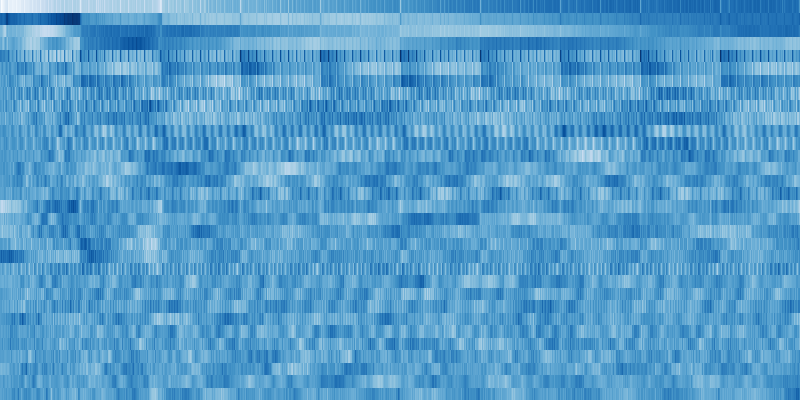

In [111]:
input_ids = tokenizer([str(i) for i in range(1000)], return_tensors="pt", add_special_tokens=False).input_ids.flatten()
embs = model.model.embed_tokens(input_ids).detach()
vis_emb(pca(embs, 32).T, colorful=True).resize((800, 400), PIL.Image.NEAREST)

In [143]:
targets = torch.arange(1000)
heldout_mask = torch.rand(1000) < 0.2  # hold out 20% of tokens for eval
probe = SinClassifier(emb_dim=embs.shape[-1], hidden_dim=32, choices=targets, heldout_mask=heldout_mask)
optim = torch.optim.Adam(probe.parameters(), lr=1e-3, weight_decay=1e-3)
for i in range(1001):
    optim.zero_grad()
    logits = probe(embs, holdout_eval_tokens=True)
    loss = torch.nn.functional.cross_entropy(logits, targets)
    loss.backward()
    optim.step()
    if i % 100 == 0:
        logits = probe(embs, holdout_eval_tokens=False)[~heldout_mask]
        acc = (logits.argmax(dim=-1) == targets[~heldout_mask]).float().mean()
        print(f"Step {i}, loss {loss.item():.4f}, acc {acc.item():.4f}")


Step 0, loss inf, acc 0.0000
Step 100, loss inf, acc 0.2021
Step 200, loss inf, acc 0.6847
Step 300, loss inf, acc 0.8507
Step 400, loss inf, acc 0.9176
Step 500, loss inf, acc 0.9653
Step 600, loss inf, acc 0.9884
Step 700, loss inf, acc 0.9884
Step 800, loss inf, acc 0.9949
Step 900, loss inf, acc 0.9974
Step 1000, loss inf, acc 0.9974


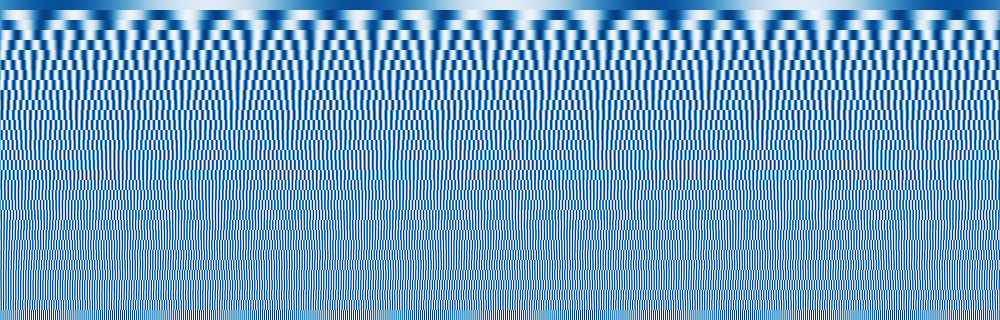

In [144]:
waves = probe.get_waves()
vis_emb(waves, colorful=True).resize((1000, 320), PIL.Image.NEAREST)